## ConvNeXt-Tiny

Training the ConvNeXt-Tiny CNN, testing how using a pretrained model, data augmentation, regularization and LR scheduler affect the performance.<br>
We are also interested in how ConvNeXt performs in comparison with ResNet.

In [1]:
from helper_functions import build_dataloaders, build_model, train_model, plot_history, evaluate_model

### ConvNeXt-Tiny basic

- No pretraining
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 29.44% | Val: 33.60% | LR: 0.000100
Epoch 2/10 | Train: 36.35% | Val: 33.74% | LR: 0.000100
Epoch 3/10 | Train: 37.96% | Val: 37.67% | LR: 0.000100
Epoch 4/10 | Train: 40.48% | Val: 37.94% | LR: 0.000100
Epoch 5/10 | Train: 40.63% | Val: 40.24% | LR: 0.000100
Epoch 6/10 | Train: 42.09% | Val: 39.84% | LR: 0.000100
Epoch 7/10 | Train: 44.07% | Val: 37.67% | LR: 0.000100
Epoch 8/10 | Train: 43.31% | Val: 39.57% | LR: 0.000100
Epoch 9/10 | Train: 45.62% | Val: 42.95% | LR: 0.000100
Epoch 10/10 | Train: 47.27% | Val: 41.87% | LR: 0.000100


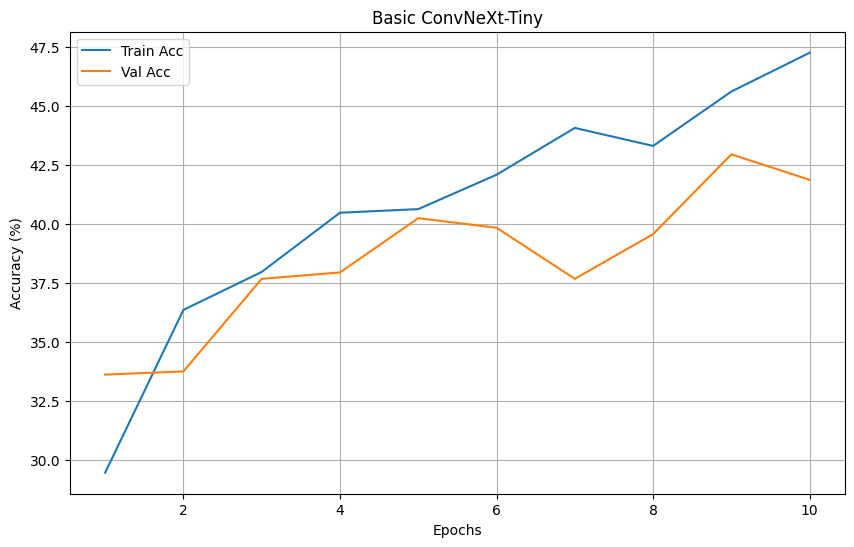


Final Test Accuracy: 46.44%


In [2]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=False
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Basic ConvNeXt-Tiny")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ConvNeXt-Tiny

- Using a pretrained model
- No augmentation, regularization
- No LR scheduler

Epoch 1/10 | Train: 31.19% | Val: 37.94% | LR: 0.000100
Epoch 2/10 | Train: 42.41% | Val: 43.63% | LR: 0.000100
Epoch 3/10 | Train: 47.22% | Val: 47.29% | LR: 0.000100
Epoch 4/10 | Train: 50.03% | Val: 47.02% | LR: 0.000100
Epoch 5/10 | Train: 57.18% | Val: 52.85% | LR: 0.000100
Epoch 6/10 | Train: 64.24% | Val: 52.57% | LR: 0.000100
Epoch 7/10 | Train: 72.14% | Val: 50.81% | LR: 0.000100
Epoch 8/10 | Train: 82.51% | Val: 49.73% | LR: 0.000100
Epoch 9/10 | Train: 90.14% | Val: 51.90% | LR: 0.000100
Epoch 10/10 | Train: 93.17% | Val: 51.76% | LR: 0.000100


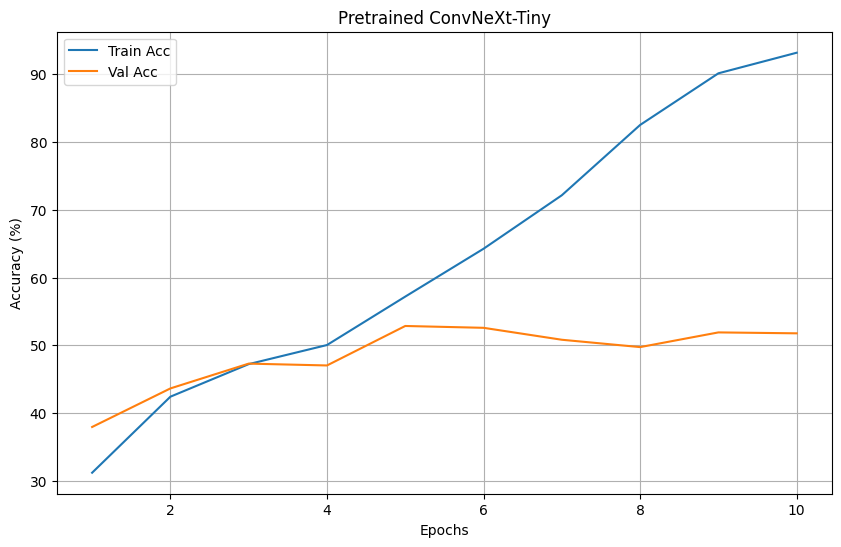


Final Test Accuracy: 57.00%


In [3]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=False
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=10)

plot_history(history, "Pretrained ConvNeXt-Tiny")

test_accuracy = evaluate_model(model, test_loader)

### Pretrained ConvNeXt-Tiny with regularization

- Using a pretrained model
- Using augmentation and regularization
- No LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/25 | Train: 17.52% | Val: 17.07% | LR: 0.000100
Epoch 2/25 | Train: 30.03% | Val: 35.50% | LR: 0.000100
Epoch 3/25 | Train: 38.25% | Val: 35.23% | LR: 0.000100
Epoch 4/25 | Train: 39.15% | Val: 39.84% | LR: 0.000100
Epoch 5/25 | Train: 40.31% | Val: 36.99% | LR: 0.000100
Epoch 6/25 | Train: 41.04% | Val: 39.57% | LR: 0.000100
Epoch 7/25 | Train: 41.71% | Val: 43.22% | LR: 0.000100
Epoch 8/25 | Train: 42.75% | Val: 40.24% | LR: 0.000100
Epoch 9/25 | Train: 43.43% | Val: 39.43% | LR: 0.000100
Epoch 10/25 | Train: 44.23% | Val: 39.84% | LR: 0.000100
Epoch 11/25 | Train: 45.25% | Val: 43.50% | LR: 0.000100
Epoch 12/25 | Train: 44.99% | Val: 44.04% | LR: 0.000100
Epoch 13/25 | Train: 45.64% | Val: 41.06% | LR: 0.000100
Epoch 14/25 | Train: 46.55% | Val: 43.63% | LR: 0.000100
Epoch 15/25 | Train: 46.66% | Val: 43.77% | LR: 0.000100
Epoch 16/25 | Train: 47.33% | Val: 44.17% | LR: 0.000100
Epoch 17/25 | Train: 47.16% | Val: 45.39% | LR: 0.000100
Epoch 18/25 | Train: 47.83% | Val: 44.85

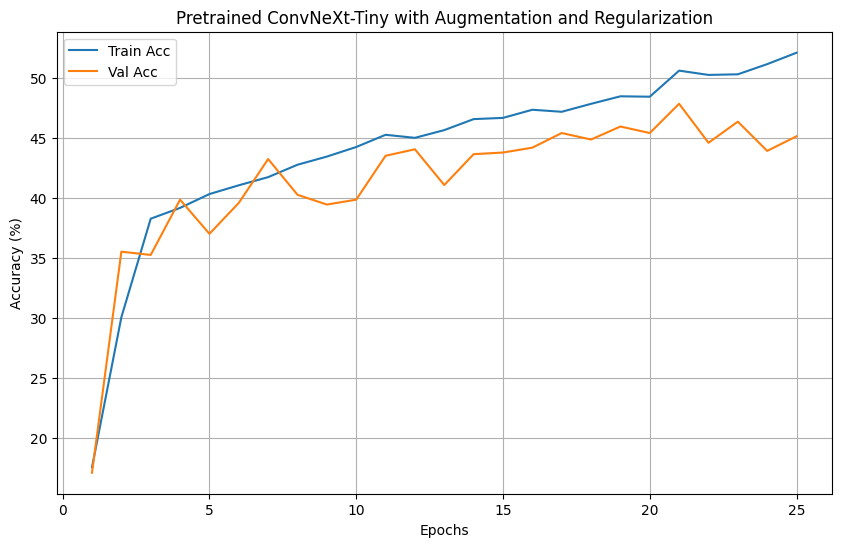


Final Test Accuracy: 50.86%


In [4]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3
)

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, epochs=25)

plot_history(history, "Pretrained ConvNeXt-Tiny with Augmentation and Regularization")

test_accuracy = evaluate_model(model, test_loader)

### ConvNeXt-Tiny final version (using everything)

- Using a pretrained model
- Using augmentation and regularization
- Using LR scheduler

Regularization:
- Data Augmentation (Gaussian nose). TODO: Try pitch etc...
- Frequency and time masking
- Dropout
- Label smoothing
- Weight decay

Epoch 1/25 | Train: 20.03% | Val: 32.25% | LR: 0.000100
Epoch 2/25 | Train: 35.16% | Val: 37.94% | LR: 0.000100
Epoch 3/25 | Train: 39.13% | Val: 37.53% | LR: 0.000100
Epoch 4/25 | Train: 40.92% | Val: 42.01% | LR: 0.000100
Epoch 5/25 | Train: 42.92% | Val: 40.24% | LR: 0.000100
Epoch 6/25 | Train: 44.55% | Val: 41.46% | LR: 0.000100
Epoch 7/25 | Train: 44.11% | Val: 41.46% | LR: 0.000050
Epoch 8/25 | Train: 46.69% | Val: 43.36% | LR: 0.000050
Epoch 9/25 | Train: 47.23% | Val: 44.31% | LR: 0.000050
Epoch 10/25 | Train: 48.59% | Val: 45.39% | LR: 0.000050
Epoch 11/25 | Train: 48.88% | Val: 48.10% | LR: 0.000050
Epoch 12/25 | Train: 49.86% | Val: 46.88% | LR: 0.000050
Epoch 13/25 | Train: 49.51% | Val: 47.97% | LR: 0.000050
Epoch 14/25 | Train: 52.21% | Val: 46.61% | LR: 0.000025
Epoch 15/25 | Train: 53.12% | Val: 50.00% | LR: 0.000025
Epoch 16/25 | Train: 54.28% | Val: 49.46% | LR: 0.000025
Epoch 17/25 | Train: 54.47% | Val: 47.29% | LR: 0.000025
Epoch 18/25 | Train: 55.04% | Val: 50.14

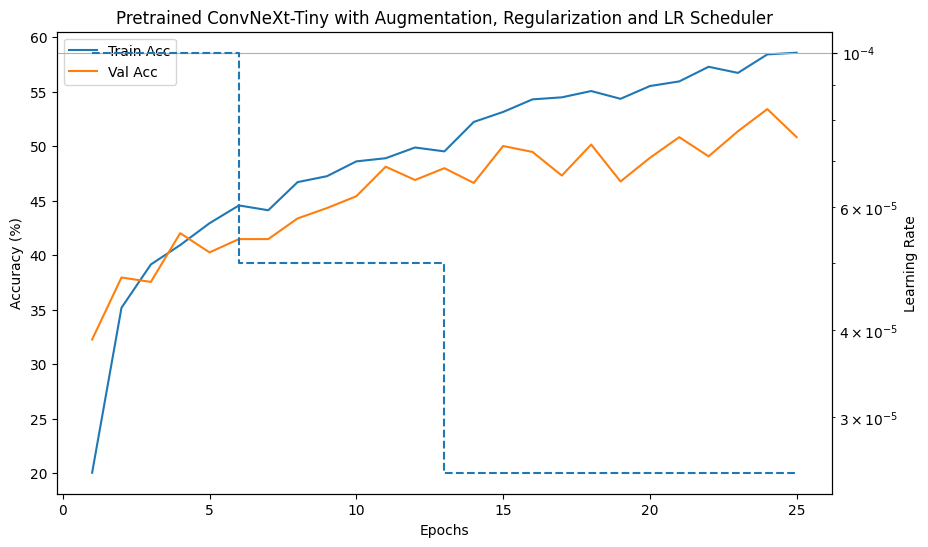


Final Test Accuracy: 56.76%


In [5]:
train_loader, val_loader, test_loader = build_dataloaders(
    "./features/mel_spectrograms",
    use_augmentation=True,
    add_noise_std=0.005,
    freq_mask_param=15,
    time_mask_param=30
)

model, criterion, optimizer, scheduler = build_model(
    model_name="convnext_tiny",
    pretrained=True,
    use_regularization=True,
    dropout_rate=0.5,
    label_smoothing=0.1,
    weight_decay=1e-3,
    use_scheduler=True,
    scheduler_factor=0.5,
    scheduler_patience=2
)

history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=scheduler,
    epochs=25
)

plot_history(history, "Pretrained ConvNeXt-Tiny with Augmentation, Regularization and LR Scheduler")

test_accuracy = evaluate_model(model, test_loader)